## Basics of Forecasting: NBA Data Set

### 1. Data Preparation

In [ ]:
# Connect to Google Drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
#Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf

In [ ]:
#Import Data
NBA = pd.read_csv("/content/drive/MyDrive/Sports Performance Analytics Michigan/Course 3 - Prediction Models with Sports Data/Week 1 Content/Week 1 Assignment Part 2/NBA_Games2.csv")

In [ ]:
# Extract 2017 regular season records, named “NBA17”.
NBA17 = NBA[(NBA.SEASON_ID == 22017) & (NBA.GAME_ID < 1000000000)].copy()
display(NBA17)

,CITY,TEAM_NAME,TEAM_ID,NICKNAME,STATE,YEAR_FOUNDED,SEASON_ID,TEAM_ABBREVIATION,GAME_ID,GAME_DATE,...,OREB,DREB,REB,AST,STL,BLK,TOV,PF,PLUS_MINUS,WIN
101,Atlanta,Atlanta Hawks,1610612737,Hawks,Atlanta,1949,22017,ATL,21701214,2018-04-10,...,8,31,39,27,10,3,10,24,-8.0,0
102,Atlanta,Atlanta Hawks,1610612737,Hawks,Atlanta,1949,22017,ATL,21701202,2018-04-08,...,5,32,37,23,7,4,13,19,6.0,1
103,Atlanta,Atlanta Hawks,1610612737,Hawks,Atlanta,1949,22017,ATL,21701184,2018-04-06,...,7,43,50,24,5,5,18,22,6.0,1
104,Atlanta,Atlanta Hawks,1610612737,Hawks,Atlanta,1949,22017,ATL,21701172,2018-04-04,...,10,38,48,20,5,6,15,16,-29.0,0
105,Atlanta,Atlanta Hawks,1610612737,Hawks,Atlanta,1949,22017,ATL,21701158,2018-04-03,...,12,37,49,24,10,1,15,15,-3.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18106,Charlotte,Charlotte Hornets,1610612766,Hornets,North Carolina,1988,22017,CHA,21700070,2017-10-27,...,11,33,44,16,6,5,9,14,-16.0,0
18107,Charlotte,Charlotte Hornets,1610612766,Hornets,North Carolina,1988,22017,CHA,21700055,2017-10-25,...,10,40,50,17,5,5,14,16,17.0,1
18108,Charlotte,Charlotte Hornets,1610612766,Hornets,North Carolina,1988,22017,CHA,21700044,2017-10-23,...,10,38,48,17,3,5,14,21,-7.0,0
18109,Charlotte,Charlotte Hornets,1610612766,Hornets,North Carolina,1988,22017,CHA,21700017,2017-10-20,...,12,45,57,17,5,4,21,18,18.0,1


In [ ]:
# Explore the data set.
NBA17.shape

(2378, 33)

In [ ]:
NBA17.columns

Index(['CITY', 'TEAM_NAME', 'TEAM_ID', 'NICKNAME', 'STATE', 'YEAR_FOUNDED',
       'SEASON_ID', 'TEAM_ABBREVIATION', 'GAME_ID', 'GAME_DATE', 'MATCHUP',
       'WL', 'MIN', 'PTS', 'FGM', 'FGA', 'FG_PCT', 'FG3M', 'FG3A', 'FG3_PCT',
       'FTM', 'FTA', 'FT_PCT', 'OREB', 'DREB', 'REB', 'AST', 'STL', 'BLK',
       'TOV', 'PF', 'PLUS_MINUS', 'WIN'],
      dtype='object')

In [ ]:
NBA17.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2378 entries, 101 to 18110
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CITY               2378 non-null   object 
 1   TEAM_NAME          2378 non-null   object 
 2   TEAM_ID            2378 non-null   int64  
 3   NICKNAME           2378 non-null   object 
 4   STATE              2378 non-null   object 
 5   YEAR_FOUNDED       2378 non-null   int64  
 6   SEASON_ID          2378 non-null   int64  
 7   TEAM_ABBREVIATION  2378 non-null   object 
 8   GAME_ID            2378 non-null   int64  
 9   GAME_DATE          2378 non-null   object 
 10  MATCHUP            2378 non-null   object 
 11  WL                 2378 non-null   object 
 12  MIN                2378 non-null   int64  
 13  PTS                2378 non-null   int64  
 14  FGM                2378 non-null   int64  
 15  FGA                2378 non-null   int64  
 16  FG_PCT             2378 no

In [ ]:
NBA17.describe().round(decimals=3).round({"comp_id":0,"gid":0,"tid":0,"year":0})

,TEAM_ID,YEAR_FOUNDED,SEASON_ID,GAME_ID,MIN,PTS,FGM,FGA,FG_PCT,FG3M,...,OREB,DREB,REB,AST,STL,BLK,TOV,PF,PLUS_MINUS,WIN
count,2.378000e+03,2378.000,2378.0,2.378000e+03,2378.000,2378.000,2378.000,2378.000,2378.000,2378.000,...,2378.000,2378.000,2378.000,2378.000,2378.000,2378.000,2378.000,2378.000,2378.000,2378.0
mean,1.610613e+09,1969.690,22017.0,2.170061e+07,241.516,106.242,39.585,86.082,0.461,10.526,...,9.696,33.807,43.503,23.268,7.719,4.825,13.660,19.848,0.006,0.5
std,8.744000e+00,16.702,0.0,3.551610e+02,6.645,12.084,5.118,6.856,0.055,3.576,...,3.629,5.324,6.362,5.223,2.920,2.521,3.722,4.227,13.839,0.5
min,1.610613e+09,1946.000,22017.0,2.170000e+07,237.000,69.000,22.000,66.000,0.282,1.000,...,0.000,18.000,22.000,9.000,0.000,0.000,3.000,8.000,-61.000,0.0
25%,1.610613e+09,1949.000,22017.0,2.170031e+07,240.000,98.000,36.000,81.000,0.423,8.000,...,7.000,30.000,39.000,20.000,6.000,3.000,11.000,17.000,-9.000,0.0
50%,1.610613e+09,1970.000,22017.0,2.170062e+07,240.000,106.000,39.000,86.000,0.460,10.000,...,9.000,34.000,43.000,23.000,8.000,5.000,14.000,20.000,-1.000,0.0
75%,1.610613e+09,1980.000,22017.0,2.170092e+07,241.000,114.000,43.000,91.000,0.495,13.000,...,12.000,37.000,48.000,27.000,10.000,6.000,16.000,23.000,9.000,1.0
max,1.610613e+09,2002.000,22017.0,2.170123e+07,317.000,149.000,58.000,114.000,0.667,24.000,...,23.000,56.000,68.000,46.000,17.000,16.000,29.000,42.000,61.000,1.0


In [ ]:
# Keep game date, gameid, points, team name, plus minus,WIN
# Drop the rest (unnecessary columns)
NBA17.drop(['CITY','TEAM_ID','NICKNAME','STATE','YEAR_FOUNDED','SEASON_ID','TEAM_ABBREVIATION','MATCHUP','WL','MIN','FGM','FGA','FG_PCT','FG3M','FG3A','FG3_PCT','FTM','FTA','FT_PCT','OREB','DREB','REB','AST','STL','BLK','TOV','PF'], axis=1, inplace=True)
NBA17

,TEAM_NAME,GAME_ID,GAME_DATE,PTS,PLUS_MINUS,WIN
101,Atlanta Hawks,21701214,2018-04-10,113,-8.0,0
102,Atlanta Hawks,21701202,2018-04-08,112,6.0,1
103,Atlanta Hawks,21701184,2018-04-06,103,6.0,1
104,Atlanta Hawks,21701172,2018-04-04,86,-29.0,0
105,Atlanta Hawks,21701158,2018-04-03,98,-3.0,0
...,...,...,...,...,...,...
18106,Charlotte Hornets,21700070,2017-10-27,93,-16.0,0
18107,Charlotte Hornets,21700055,2017-10-25,110,17.0,1
18108,Charlotte Hornets,21700044,2017-10-23,94,-7.0,0
18109,Charlotte Hornets,21700017,2017-10-20,109,18.0,1


In [ ]:
# Create Points_For and Points_Against variables
NBA17['Points_For'] = NBA17['PTS']
NBA17['Points_Against'] = NBA17['Points_For'] - NBA17['PLUS_MINUS']

In [ ]:
# Now we choose the games played in the calendar year of 2017 to obtain the pythagorean win % and win % as basis for forecasting
NBA17_1st =  NBA17[NBA17.GAME_ID <= 21700615].copy()
NBA17_1st

,TEAM_NAME,GAME_ID,GAME_DATE,PTS,PLUS_MINUS,WIN,Points_For,Points_Against
142,Atlanta Hawks,21700612,2018-01-10,110,13.4,1,110,96.6
143,Atlanta Hawks,21700598,2018-01-08,107,-1.0,0,107,108.0
144,Atlanta Hawks,21700590,2018-01-07,113,-19.0,0,113,132.0
145,Atlanta Hawks,21700576,2018-01-05,89,-21.0,0,89,110.0
146,Atlanta Hawks,21700551,2018-01-02,103,-1.0,0,103,104.0
...,...,...,...,...,...,...,...,...
18106,Charlotte Hornets,21700070,2017-10-27,93,-16.0,0,93,109.0
18107,Charlotte Hornets,21700055,2017-10-25,110,17.0,1,110,93.0
18108,Charlotte Hornets,21700044,2017-10-23,94,-7.0,0,94,101.0
18109,Charlotte Hornets,21700017,2017-10-20,109,18.0,1,109,91.0


In [ ]:
# Extract the 2nd half of the season (games played in the calendar year of 2018)
NBA17_2nd =  NBA17[NBA17.GAME_ID > 21700615].copy()
NBA17_2nd

,TEAM_NAME,GAME_ID,GAME_DATE,PTS,PLUS_MINUS,WIN,Points_For,Points_Against
101,Atlanta Hawks,21701214,2018-04-10,113,-8.0,0,113,121.0
102,Atlanta Hawks,21701202,2018-04-08,112,6.0,1,112,106.0
103,Atlanta Hawks,21701184,2018-04-06,103,6.0,1,103,97.0
104,Atlanta Hawks,21701172,2018-04-04,86,-29.0,0,86,115.0
105,Atlanta Hawks,21701158,2018-04-03,98,-3.0,0,98,101.0
...,...,...,...,...,...,...,...,...
18067,Charlotte Hornets,21700676,2018-01-20,105,-1.0,0,105,106.0
18068,Charlotte Hornets,21700653,2018-01-17,133,24.0,1,133,109.0
18069,Charlotte Hornets,21700638,2018-01-15,118,11.0,1,118,107.0
18070,Charlotte Hornets,21700629,2018-01-13,91,-10.0,0,91,101.0


###Creating Additional Variables in the 2017 half of the Season:

In [ ]:
# Aggregate game level statistics to a group (i.e., team) level statistics
NBA17_pre = NBA17_1st.groupby(['TEAM_NAME'])[['WIN','Points_For','Points_Against']].sum()
NBA17_pre

,WIN,Points_For,Points_Against
TEAM_NAME,,,
Atlanta Hawks,11,4262,4443.6
Boston Celtics,34,4532,4299.8
Brooklyn Nets,15,4342,4473.6
Charlotte Hornets,15,4102,4140.0
Chicago Bulls,15,4295,4551.0
Cleveland Cavaliers,26,4506,4460.0
Dallas Mavericks,15,4410,4490.0
Denver Nuggets,21,4400,4355.2
Detroit Pistons,22,4088,4052.0


In [ ]:
# Obtain the number of games played by each team for the 1st half of the 2017 regular season
NBA_pre_GameNum = NBA17_1st.groupby(['TEAM_NAME']).size().reset_index(name='game_count')
NBA_pre_GameNum

,TEAM_NAME,game_count
0,Atlanta Hawks,41
1,Boston Celtics,44
2,Brooklyn Nets,41
3,Charlotte Hornets,39
4,Chicago Bulls,42
5,Cleveland Cavaliers,41
6,Dallas Mavericks,43
7,Denver Nuggets,41
8,Detroit Pistons,40
9,Golden State Warriors,42


In [ ]:
# Merge total number of games to the dataset
NBA17_pre=pd.merge(NBA17_pre, NBA_pre_GameNum, on=['TEAM_NAME'])
NBA17_pre

,TEAM_NAME,WIN,Points_For,Points_Against,game_count
0,Atlanta Hawks,11,4262,4443.6,41
1,Boston Celtics,34,4532,4299.8,44
2,Brooklyn Nets,15,4342,4473.6,41
3,Charlotte Hornets,15,4102,4140.0,39
4,Chicago Bulls,15,4295,4551.0,42
5,Cleveland Cavaliers,26,4506,4460.0,41
6,Dallas Mavericks,15,4410,4490.0,43
7,Denver Nuggets,21,4400,4355.2,41
8,Detroit Pistons,22,4088,4052.0,40
9,Golden State Warriors,33,4861,4475.0,42


In [ ]:
NBA17_pre['win_pct_pre']=NBA17_pre['WIN']/NBA17_pre['game_count']
NBA17_pre['pyth_wpct_pre']=NBA17_pre['Points_For']**2/(NBA17_pre['Points_For']**2+NBA17_pre['Points_Against']**2)
NBA17_pre

,TEAM_NAME,WIN,Points_For,Points_Against,game_count,win_pct_pre,pyth_wpct_pre
0,Atlanta Hawks,11,4262,4443.6,41,0.268293,0.479149
1,Boston Celtics,34,4532,4299.8,44,0.772727,0.526273
2,Brooklyn Nets,15,4342,4473.6,41,0.365854,0.485075
3,Charlotte Hornets,15,4102,4140.0,39,0.384615,0.495390
4,Chicago Bulls,15,4295,4551.0,42,0.357143,0.471085
5,Cleveland Cavaliers,26,4506,4460.0,41,0.634146,0.505130
6,Dallas Mavericks,15,4410,4490.0,43,0.348837,0.491012
7,Denver Nuggets,21,4400,4355.2,41,0.512195,0.505117
8,Detroit Pistons,22,4088,4052.0,40,0.550000,0.504423
9,Golden State Warriors,33,4861,4475.0,42,0.785714,0.541275


In [ ]:
# Drop unnecessary variables
NBA17_pre.drop(['Points_For','Points_Against','game_count','WIN'], axis=1, inplace=True)
NBA17_pre

,TEAM_NAME,win_pct_pre,pyth_wpct_pre
0,Atlanta Hawks,0.268293,0.479149
1,Boston Celtics,0.772727,0.526273
2,Brooklyn Nets,0.365854,0.485075
3,Charlotte Hornets,0.384615,0.495390
4,Chicago Bulls,0.357143,0.471085
5,Cleveland Cavaliers,0.634146,0.505130
6,Dallas Mavericks,0.348837,0.491012
7,Denver Nuggets,0.512195,0.505117
8,Detroit Pistons,0.550000,0.504423
9,Golden State Warriors,0.785714,0.541275


###Creating Additional Variables in the 2018 half of the Season:

In [ ]:
# Aggregate game level statistics to a group (i.e., team) level statistics
NBA17_post = NBA17_2nd.groupby(['TEAM_NAME'])[['WIN']].sum()
NBA17_post

,WIN
TEAM_NAME,
Atlanta Hawks,13
Boston Celtics,21
Brooklyn Nets,13
Charlotte Hornets,21
Chicago Bulls,12
Cleveland Cavaliers,24
Dallas Mavericks,9
Denver Nuggets,25
Detroit Pistons,17


In [ ]:
# Obtain the number of games played by each team for the 2nd half of the 2017 regular season
NBA_post_GameNum = NBA17_2nd.groupby(['TEAM_NAME']).size().reset_index(name='game_count')
NBA_post_GameNum

,TEAM_NAME,game_count
0,Atlanta Hawks,41
1,Boston Celtics,38
2,Brooklyn Nets,41
3,Charlotte Hornets,43
4,Chicago Bulls,40
5,Cleveland Cavaliers,41
6,Dallas Mavericks,39
7,Denver Nuggets,41
8,Detroit Pistons,42
9,Golden State Warriors,40


In [ ]:
# Merge total number of games to the dataset
NBA17_post=pd.merge(NBA17_post, NBA_post_GameNum, on=['TEAM_NAME'])
NBA17_post

,TEAM_NAME,WIN,game_count
0,Atlanta Hawks,13,41
1,Boston Celtics,21,38
2,Brooklyn Nets,13,41
3,Charlotte Hornets,21,43
4,Chicago Bulls,12,40
5,Cleveland Cavaliers,24,41
6,Dallas Mavericks,9,39
7,Denver Nuggets,25,41
8,Detroit Pistons,17,42
9,Golden State Warriors,25,40


In [ ]:
NBA17_post['win_pct_post']=NBA17_post['WIN']/NBA17_post['game_count']
NBA17_post

,TEAM_NAME,WIN,game_count,win_pct_post
0,Atlanta Hawks,13,41,0.317073
1,Boston Celtics,21,38,0.552632
2,Brooklyn Nets,13,41,0.317073
3,Charlotte Hornets,21,43,0.488372
4,Chicago Bulls,12,40,0.300000
5,Cleveland Cavaliers,24,41,0.585366
6,Dallas Mavericks,9,39,0.230769
7,Denver Nuggets,25,41,0.609756
8,Detroit Pistons,17,42,0.404762
9,Golden State Warriors,25,40,0.625000


In [ ]:
# Drop unnecessary variables
NBA17_post.drop(['game_count','WIN'], axis=1, inplace=True)
NBA17_post

,TEAM_NAME,win_pct_post
0,Atlanta Hawks,0.317073
1,Boston Celtics,0.552632
2,Brooklyn Nets,0.317073
3,Charlotte Hornets,0.488372
4,Chicago Bulls,0.300000
5,Cleveland Cavaliers,0.585366
6,Dallas Mavericks,0.230769
7,Denver Nuggets,0.609756
8,Detroit Pistons,0.404762
9,Golden State Warriors,0.625000


###Plotting and Forecasting:

In [ ]:
NBA_Stats=pd.merge(NBA17_pre, NBA17_post, on=['TEAM_NAME'])
NBA_Stats

,TEAM_NAME,win_pct_pre,pyth_wpct_pre,win_pct_post
0,Atlanta Hawks,0.268293,0.479149,0.317073
1,Boston Celtics,0.772727,0.526273,0.552632
2,Brooklyn Nets,0.365854,0.485075,0.317073
3,Charlotte Hornets,0.384615,0.495390,0.488372
4,Chicago Bulls,0.357143,0.471085,0.300000
5,Cleveland Cavaliers,0.634146,0.505130,0.585366
6,Dallas Mavericks,0.348837,0.491012,0.230769
7,Denver Nuggets,0.512195,0.505117,0.609756
8,Detroit Pistons,0.550000,0.504423,0.404762
9,Golden State Warriors,0.785714,0.541275,0.625000


Text(0.5, 1.0, 'Correlation: Pre-win% vs Post-win%')

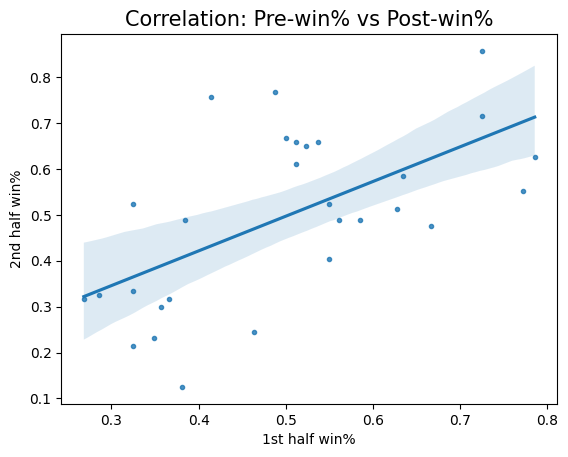

In [ ]:
# Correlation of the win_pct_pre and win_pct_post variables
sns.regplot(x='win_pct_pre', y='win_pct_post', data=NBA_Stats,  marker='.')
plt.xlabel('1st half win%')
plt.ylabel('2nd half win%')
plt.title("Correlation: Pre-win% vs Post-win%", fontsize=15)

In [ ]:
# Run the regression using win% from the 1st half of the regular season
WinPct_lm = smf.ols(formula = 'win_pct_post ~ win_pct_pre', data=NBA_Stats).fit()
WinPct_lm.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:           win_pct_post   R-squared:                       0.363
Model:                            OLS   Adj. R-squared:                  0.340
Method:                 Least Squares   F-statistic:                     15.40
Date:                Thu, 20 Aug 2026   Prob (F-statistic):           0.000541
Time:                        23:45:35   Log-Likelihood:                 14.429
No. Observations:                  29   AIC:                            -24.86
Df Residuals:                      27   BIC:                            -22.12
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
===============================================================================
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
Intercept       0.1191      0.100      1.186      0.246      -0.087       0.325
win_pct_pre     0.7558      0.193      3.924      0.001       0.361       1.151
==============================================================================
Omnibus:                        0.868   Durbin-Watson:                   2.640
Prob(Omnibus):                  0.648   Jarque-Bera (JB):                0.904
Skew:                           0.316   Prob(JB):                        0.637
Kurtosis:                       2.409   Cond. No.                         8.53
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

Text(0.5, 1.0, 'Correlation: Pre-Pyth.win% vs Post-win%')

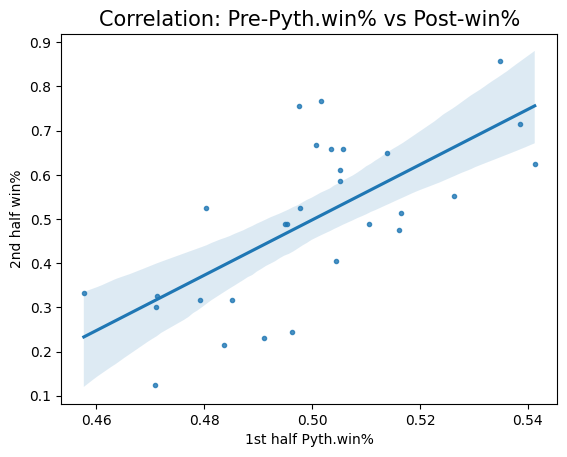

In [ ]:
# Correlation of the pyth_wpct_pre and win_pct_post variables
sns.regplot(x='pyth_wpct_pre', y='win_pct_post', data=NBA_Stats,  marker='.')
plt.xlabel('1st half Pyth.win%')
plt.ylabel('2nd half win%')
plt.title("Correlation: Pre-Pyth.win% vs Post-win%", fontsize=15)

In [ ]:
# Run the regression using pyth_win% from the 1st half of the regular season
PythWin_lm = smf.ols(formula = 'win_pct_post ~ pyth_wpct_pre', data=NBA_Stats).fit()
PythWin_lm.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:           win_pct_post   R-squared:                       0.469
Model:                            OLS   Adj. R-squared:                  0.449
Method:                 Least Squares   F-statistic:                     23.86
Date:                Thu, 20 Aug 2026   Prob (F-statistic):           4.15e-05
Time:                        23:45:35   Log-Likelihood:                 17.068
No. Observations:                  29   AIC:                            -30.14
Df Residuals:                      27   BIC:                            -27.40
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
=================================================================================
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
Intercept        -2.6293      0.641     -4.105      0.000      -3.944      -1.315
pyth_wpct_pre     6.2544      1.280      4.885      0.000       3.627       8.881
==============================================================================
Omnibus:                        1.068   Durbin-Watson:                   2.689
Prob(Omnibus):                  0.586   Jarque-Bera (JB):                0.898
Skew:                           0.166   Prob(JB):                        0.638
Kurtosis:                       2.204   Cond. No.                         61.9
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [ ]:
# Model Comparison
from statsmodels.iolib.summary2 import summary_col
info_dict={'R-squared' : lambda x: f"{x.rsquared:.2f}"}
Header = ['1','2']
Table_1 = summary_col([WinPct_lm, PythWin_lm,],\
                      regressor_order=['Intercept','Win%','Pyth.Win%'], model_names = Header, info_dict=info_dict)
print(Table_1)


                  1        2    
--------------------------------
Intercept      0.1191   -2.6293 
               (0.1004) (0.6405)
win_pct_pre    0.7558           
               (0.1926)         
pyth_wpct_pre           6.2544  
                        (1.2804)
R-squared      0.3632   0.4692  
R-squared Adj. 0.3396   0.4495  
R-squared      0.36     0.47    
Standard errors in parentheses.


Therefore, the our second model gives us the better R-Squared (0.3632 vs 0.4692) validating the claim that the first half pythagorean win percentage is a better predictor of second half win percentage than first half win percentage is.

## The End